# DAI Mission Proposal
**Data & AI in Economics | TU Dortmund**


## 1. Team

| Role | Name |
|------|------|
| Lead | Christy Johns | 
| Member | Armaan Mistry |
| Member| Rohit Stanly |


## 2. Mission Title & Research Question

**Title:** *Day-Ahead Electricity Price Forecasting in Germany Using Load, Renewable, and Generation-Side Information*

**Research question:**  
*Can German hourly day-ahead electricity prices be forecast more accurately by combining price history with day-ahead load forecasts, renewable generation forecasts, residual-load information, and generation-side controls?*

**Why it matters:**  
Day-ahead electricity price forecasting is important for electricity producers, consumers, traders, and system operators because the day-ahead market is a central market for short-term electricity trading. Germany is especially relevant because wind and solar generation are weather-dependent and can strongly change the residual load, defined as load minus wind and solar generation. This project investigates whether this information improves hourly day-ahead price forecasts in a realistic setup using only information available before the day-ahead auction.


## 3. Data

**Source(s):**  
The main dataset will be constructed from the **ENTSO-E Transparency Platform** using the ENTSO-E API. It will include German-Luxembourg day-ahead prices and Germany-level system variables: load forecasts, wind forecasts, solar forecasts, total generation forecasts, and generation by production type. Optional external commodity variables such as gas, coal, oil, and EUA carbon prices may be added later if time permits.

**Unit of observation:** *One row represents one delivery hour in the German day-ahead electricity market.*

**Key variables:**

| Variable | Type | Role (feature / target / instrument / ...) | Description |
|----------|------|---------------------------------------------|-------------|
| `timestamp` | datetime | identifier | Delivery hour of the observation. |
| `da_price_eur_mwh` | numeric | target | Hourly day-ahead electricity price in EUR/MWh. |
| `load_forecast_mw` | numeric | feature | Day-ahead forecast of electricity demand. |
| `wind_forecast_mw`, `solar_forecast_mw` | numeric | feature | Day-ahead forecasts of renewable generation. |
| `residual_load_forecast_mw` | numeric | feature | Load forecast minus wind and solar forecasts. |
| `generation_forecast_total_mw` | numeric | feature | Total generation forecast, where available. |
| `da_price_lag_24h`, `da_price_lag_48h`, `da_price_lag_168h` | numeric | feature | Historical price information from previous day, two days before, and previous week. |
| `gen_lignite_actual_mw_lag_24h`, `gen_hard_coal_actual_mw_lag_24h`, `gen_gas_actual_mw_lag_24h`, `gen_oil_actual_mw_lag_24h` | numeric | feature | Lagged conventional generation controls from the previous day. |
| `gen_nuclear_actual_mw_lag_24h`, `gen_biomass_actual_mw_lag_24h`, `gen_hydro_actual_mw_lag_24h`, `gen_waste_actual_mw_lag_24h`, `gen_other_actual_mw_lag_24h` | numeric | feature | Lagged generation-side controls from other production types. |
| `gen_lignite_actual_mw_lag_168h`, `gen_hard_coal_actual_mw_lag_168h`, `gen_gas_actual_mw_lag_168h`, etc. | numeric | feature | Same-hour generation mix from one week earlier. |
| `hour`, `weekday`, `is_weekend`, `month`, `holiday_de` | numeric / categorical | feature | Calendar variables capturing daily, weekly, and seasonal patterns. |
| `hs_*` columns | numeric | optional feature | Optional probabilistic features based on historical forecast errors. These will be used only if time permits. |

**Potential data quality issues:**  
ENTSO-E time series may contain missing values, duplicate timestamps, daylight-saving-time changes, and differences between bidding-zone and country-level variables. Same-hour actual generation values such as `gen_gas_actual_mw` or `gen_lignite_actual_mw` will not be used as direct predictors because they are only known after delivery. Instead, generation by type will be used through lagged variables such as 24-hour and 168-hour lags. This directly controls for broader generation-side conditions while avoiding information leakage.


Loaded dataset from: germany_epf_model_ready_long.csv
Shape: 52,608 rows and 122 columns
Time range: 2019-01-01 00:00:00 to 2024-12-31 23:00:00

Rows by year:


C:\Users\Armaan\AppData\Local\Temp\ipykernel_31060\977193119.py:33: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df.insert(0, "timestamp", pd.date_range("2019-01-01 00:00:00", "2024-12-31 23:00:00", freq="h"))


,hourly_rows
timestamp,
2019,8760
2020,8784
2021,8760
2022,8760
2023,8760
2024,8784



Preview of selected modelling columns, including generation-side controls:


,timestamp,da_price_eur_mwh,load_forecast_mw,wind_forecast_mw,solar_forecast_mw,residual_load_forecast_mw,generation_forecast_total_mw,hour,is_weekend,month,...,gen_gas_actual_mw_lag_24h,gen_oil_actual_mw_lag_24h,gen_nuclear_actual_mw_lag_24h,gen_biomass_actual_mw_lag_24h,gen_waste_actual_mw_lag_24h,gen_lignite_actual_mw_lag_168h,gen_hard_coal_actual_mw_lag_168h,gen_gas_actual_mw_lag_168h,gen_nuclear_actual_mw_lag_168h,gen_biomass_actual_mw_lag_168h
32136,2022-09-01 00:00:00,490.77,45334.2800,10599.6675,0.0000,34734.6125,48860.06,1,0,9,...,6543.223030,290.7800,3982.1025,3927.4950,797.5100,11856.1575,9739.0375,4551.741837,3955.6975,3908.5525
32137,2022-09-01 01:00:00,484.36,43953.3675,9575.3100,0.0000,34378.0575,46902.38,2,0,9,...,6214.220747,290.8000,3980.4700,3895.8550,793.7550,11880.6900,9321.8800,4394.014553,3966.9325,3875.4375
32138,2022-09-01 02:00:00,486.34,42950.0950,8784.3550,0.0000,34165.7400,45311.36,3,0,9,...,6244.028464,292.3750,3984.7650,3886.8700,800.2600,11887.3300,9249.4400,4061.639770,3966.3250,3834.0800
32139,2022-09-01 03:00:00,480.02,42986.0725,8028.1275,0.0000,34957.9450,44523.06,4,0,9,...,6184.853680,296.1225,3992.2300,3882.5925,792.1325,11909.3775,9249.6550,4167.057487,3974.1950,3829.9975
32140,2022-09-01 04:00:00,495.18,43996.5325,7328.3725,0.0000,36668.1600,44137.97,5,0,9,...,6522.073897,296.5475,3996.5625,3906.4900,799.9500,11924.6900,9213.9850,4492.585203,3981.5825,3832.2375
32141,2022-09-01 05:00:00,532.80,47423.4375,6774.9050,0.0000,40648.5325,45783.51,6,0,9,...,7365.956613,297.1250,4000.5000,3997.2050,802.2525,11952.6225,9525.0925,4931.327920,3982.7250,3928.5850
32142,2022-09-01 06:00:00,644.71,54495.6925,6518.9100,156.6350,47820.1475,49776.37,7,0,9,...,10215.491830,298.4625,4003.3850,4224.0775,811.6625,12148.5625,9635.9250,5089.165636,3983.3125,4190.1350
32143,2022-09-01 07:00:00,669.21,58493.0875,6326.1300,2654.2475,49512.7100,54748.18,8,0,9,...,10755.142047,298.4700,4003.4975,4425.5950,808.6625,12288.3425,9853.8175,5207.600853,3984.2725,4372.5550
32144,2022-09-01 08:00:00,665.46,61481.4175,5362.5800,8859.5075,47259.3300,59619.05,9,0,9,...,10761.599763,298.4675,4008.2825,4502.2300,801.2625,12265.4625,9755.7775,5217.336070,3982.6300,4434.2700



Number of generation-side lag features available: 22


,generation_side_lag_features
0,gen_lignite_actual_mw_lag_24h
1,gen_hard_coal_actual_mw_lag_24h
2,gen_gas_actual_mw_lag_24h
3,gen_oil_actual_mw_lag_24h
4,gen_nuclear_actual_mw_lag_24h
5,gen_biomass_actual_mw_lag_24h
6,gen_waste_actual_mw_lag_24h
7,gen_lignite_actual_mw_lag_168h
8,gen_hard_coal_actual_mw_lag_168h
9,gen_gas_actual_mw_lag_168h


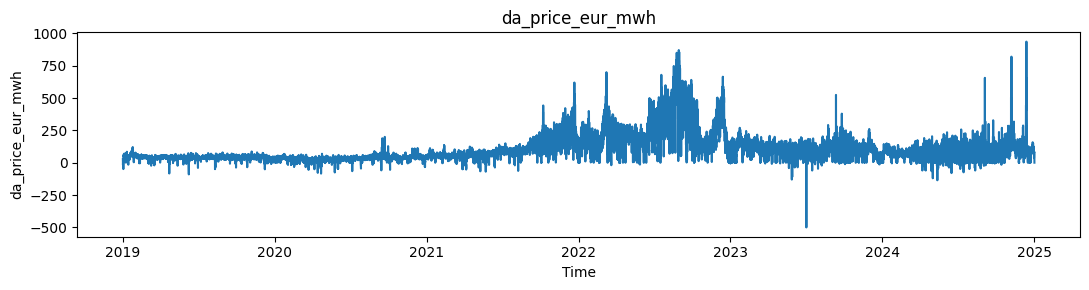

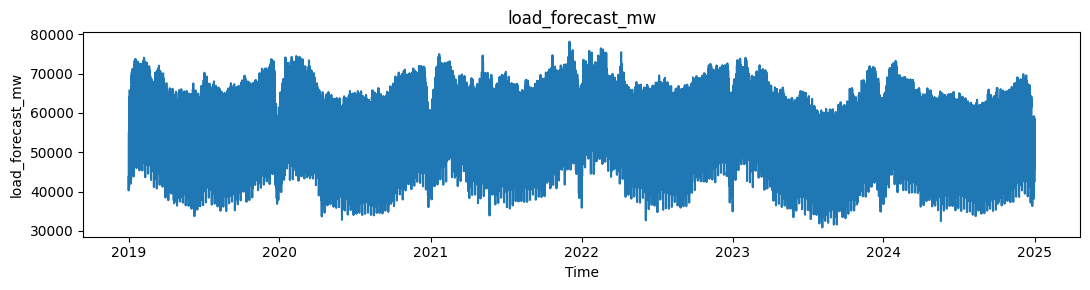

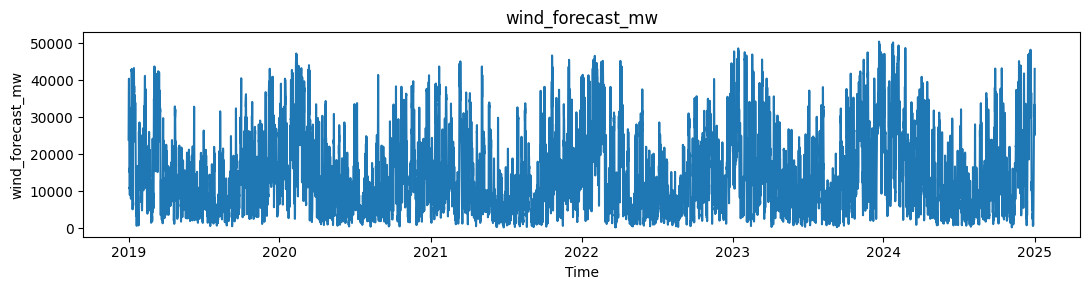

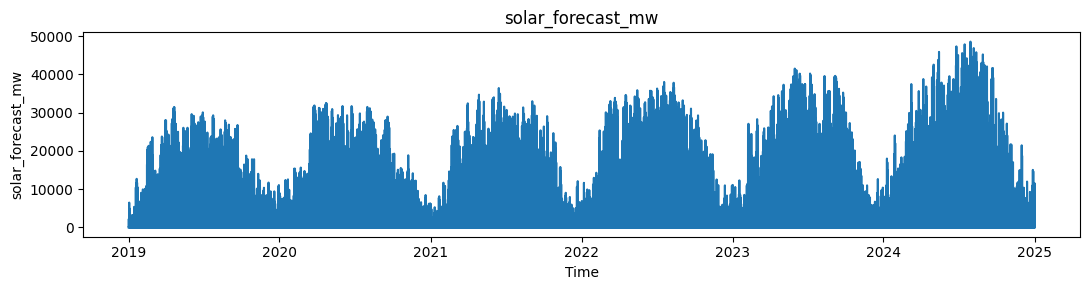

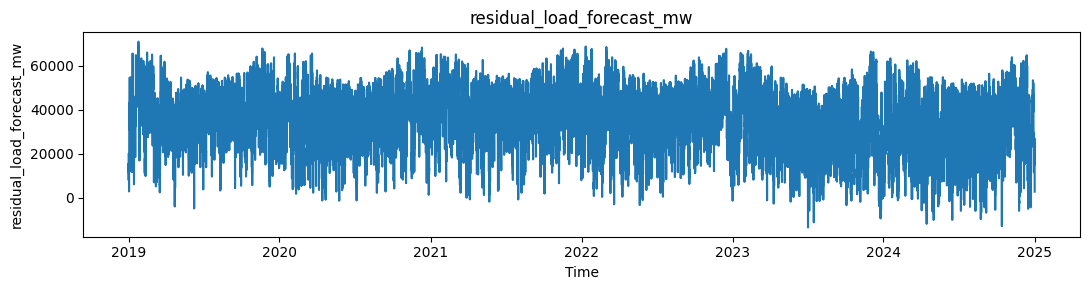

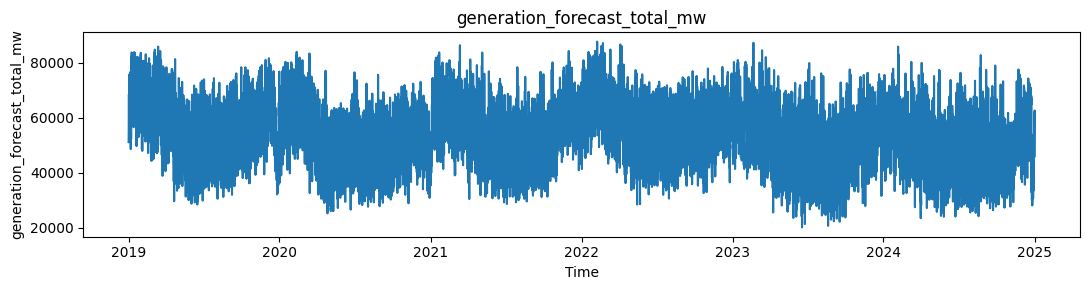


Correlation heatmap for main variables and selected generation controls:


,da_price_eur_mwh,load_forecast_mw,wind_forecast_mw,solar_forecast_mw,residual_load_forecast_mw,generation_forecast_total_mw,gen_lignite_actual_mw_lag_24h,gen_hard_coal_actual_mw_lag_24h,gen_gas_actual_mw_lag_24h,gen_oil_actual_mw_lag_24h,gen_nuclear_actual_mw_lag_24h,gen_biomass_actual_mw_lag_24h
da_price_eur_mwh,1.00,0.18,-0.28,-0.08,0.42,0.00,0.31,0.43,0.06,-0.26,-0.19,-0.04
load_forecast_mw,0.18,1.00,0.11,0.30,0.41,0.80,0.27,0.40,0.34,0.16,0.14,0.35
wind_forecast_mw,-0.28,0.11,1.00,-0.22,-0.60,0.49,-0.24,-0.09,-0.08,0.03,-0.05,0.16
solar_forecast_mw,-0.08,0.30,-0.22,1.00,-0.30,0.33,-0.21,-0.18,-0.21,0.01,-0.13,-0.31
residual_load_forecast_mw,0.42,0.41,-0.60,-0.30,1.00,-0.06,0.54,0.49,0.46,0.09,0.24,0.33
generation_forecast_total_mw,0.00,0.80,0.49,0.33,-0.06,1.00,0.16,0.35,0.20,0.16,0.22,0.34
gen_lignite_actual_mw_lag_24h,0.31,0.27,-0.24,-0.21,0.54,0.16,1.00,0.72,0.56,0.07,0.34,0.31
gen_hard_coal_actual_mw_lag_24h,0.43,0.40,-0.09,-0.18,0.49,0.35,0.72,1.00,0.57,0.07,0.23,0.34
gen_gas_actual_mw_lag_24h,0.06,0.34,-0.08,-0.21,0.46,0.20,0.56,0.57,1.00,0.24,0.15,0.39
gen_oil_actual_mw_lag_24h,-0.26,0.16,0.03,0.01,0.09,0.16,0.07,0.07,0.24,1.00,0.28,0.15


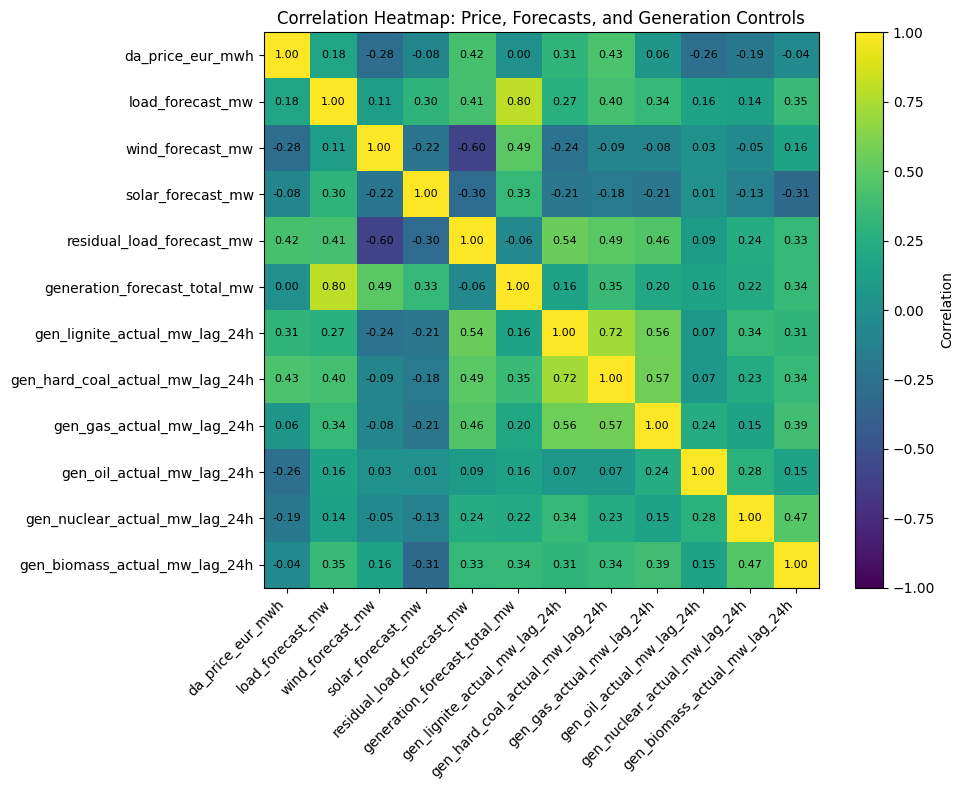

In [3]:
# Data loading & EDA preview

import pandas as pd
import numpy as np
from pathlib import Path
from IPython.display import display
import matplotlib.pyplot as plt

paths = [
    Path("germany_epf_model_ready_long.csv")
]

dataset_path = next((p for p in paths if p.exists()), None)

if dataset_path is None:
    print("Dataset file not found. Place 'germany_epf_final_dataset.csv' or 'germany_epf_model_ready_long.csv' in the working directory.")
else:
    df = pd.read_csv(dataset_path)

    # Remove unnamed index columns if present
    unnamed_cols = [c for c in df.columns if str(c).lower().startswith("unnamed")]
    if unnamed_cols:
        df = df.drop(columns=unnamed_cols)

    # Detect or reconstruct timestamp
    timestamp_col = None
    for col in ["timestamp", "datetime", "time", "date", "delivery_time", "delivery_start"]:
        if col in df.columns:
            timestamp_col = col
            break

    if timestamp_col is None and len(df) == 52608:
        df.insert(0, "timestamp", pd.date_range("2019-01-01 00:00:00", "2024-12-31 23:00:00", freq="h"))
        timestamp_col = "timestamp"

    if timestamp_col is not None:
        df[timestamp_col] = pd.to_datetime(df[timestamp_col])
        df = df.sort_values(timestamp_col).reset_index(drop=True)

    print(f"Loaded dataset from: {dataset_path}")
    print(f"Shape: {df.shape[0]:,} rows and {df.shape[1]:,} columns")

    if timestamp_col is not None:
        print(f"Time range: {df[timestamp_col].min()} to {df[timestamp_col].max()}")
        print("\nRows by year:")
        display(df[timestamp_col].dt.year.value_counts().sort_index().to_frame("hourly_rows"))

    # Core variables to display in proposal
    core_cols = [
        "timestamp", "da_price_eur_mwh",
        "load_forecast_mw", "wind_forecast_mw", "solar_forecast_mw",
        "residual_load_forecast_mw", "generation_forecast_total_mw",
        "da_price_lag_24h", "da_price_lag_48h", "da_price_lag_168h",
        "hour", "weekday", "is_weekend", "month", "holiday_de"
    ]

    # Generation-side controls: include all available lagged generation-by-type columns
    gen_lag_cols = [
        c for c in df.columns
        if c.startswith("gen_") and ("lag_24h" in c or "lag_168h" in c)
    ]

    # Prefer showing the most interpretable generation controls first
    preferred_gen_order = [
        "gen_lignite_actual_mw_lag_24h", "gen_hard_coal_actual_mw_lag_24h",
        "gen_gas_actual_mw_lag_24h", "gen_oil_actual_mw_lag_24h",
        "gen_nuclear_actual_mw_lag_24h", "gen_biomass_actual_mw_lag_24h",
        "gen_hydro_actual_mw_lag_24h", "gen_waste_actual_mw_lag_24h",
        "gen_lignite_actual_mw_lag_168h", "gen_hard_coal_actual_mw_lag_168h",
        "gen_gas_actual_mw_lag_168h", "gen_nuclear_actual_mw_lag_168h"
    ]
    gen_lag_cols = [c for c in preferred_gen_order if c in df.columns] + [c for c in gen_lag_cols if c not in preferred_gen_order]

    preview_cols = [c for c in core_cols if c in df.columns] + gen_lag_cols[:12]

    print("\nPreview of selected modelling columns, including generation-side controls:")
    preview_df = df[df[timestamp_col] >= '2022-09-01'].head(9)
    display(preview_df[preview_cols])

    print("\nNumber of generation-side lag features available:", len(gen_lag_cols))
    if gen_lag_cols:
        display(pd.DataFrame({"generation_side_lag_features": gen_lag_cols}))


    # Time-series sanity plots for main variables
    plot_cols = [
        "da_price_eur_mwh", "load_forecast_mw", "wind_forecast_mw",
        "solar_forecast_mw", "residual_load_forecast_mw", "generation_forecast_total_mw"
    ]
    plot_cols = [c for c in plot_cols if c in df.columns]

    if timestamp_col is not None:
        for col in plot_cols:
            plt.figure(figsize=(11, 3))
            plt.plot(df[timestamp_col], df[col])
            plt.title(col)
            plt.xlabel("Time")
            plt.ylabel(col)
            plt.tight_layout()
            plt.show()

    # Correlation heatmap for core variables and selected generation controls
    corr_cols = [
        "da_price_eur_mwh", "load_forecast_mw", "wind_forecast_mw",
        "solar_forecast_mw", "residual_load_forecast_mw", "generation_forecast_total_mw"
    ]
    corr_cols = [c for c in corr_cols if c in df.columns]
    corr_cols += [c for c in gen_lag_cols[:6] if c in df.columns]
    corr_cols = [c for c in corr_cols if pd.api.types.is_numeric_dtype(df[c])]

    if len(corr_cols) >= 2:
        corr = df[corr_cols].corr().round(2)
        print("\nCorrelation heatmap for main variables and selected generation controls:")
        display(corr)

        plt.figure(figsize=(10, 8))
        im = plt.imshow(corr, vmin=-1, vmax=1)
        plt.colorbar(im, label="Correlation")
        plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha="right")
        plt.yticks(range(len(corr.index)), corr.index)
        for i in range(len(corr.index)):
            for j in range(len(corr.columns)):
                plt.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8)
        plt.title("Correlation Heatmap: Price, Forecasts, and Generation Controls")
        plt.tight_layout()
        plt.show()


## 4. Planned Methods



### 4a. Causal Inference
- [x] Causal graph / DAG (DoWhy)
- [x] Backdoor adjustment
- [ ] Instrumental variable
- [ ] Propensity score stratification
- [ ] Other: ___

*Justification:*  
We will use a causal graph / DAG to clarify the assumed relationships between load, renewable forecasts, residual load, generation-side controls, calendar variables, and day-ahead prices. This helps identify possible confounders and prevents using variables that are not available before the day-ahead auction. Backdoor adjustment will be used as an exploratory step to analyse the relationship between residual load forecasts and prices while controlling for observable confounders.

### 4b. Supervised Learning
- [x] Linear / Ridge / Lasso regression
- [ ] Logistic regression
- [ ] k-Nearest Neighbors
- [ ] Support Vector Machine
- [x] Decision Tree / Random Forest
- [ ] Neural network (regression or classification)
- [x] Other: Gradient Boosting / XGBoost

*Justification:*  
The main task is hourly day-ahead electricity price forecasting. We will compare simple benchmark models with Lasso/Ridge regression and tree-based models such as Random Forest and XGBoost. Lasso is useful because the dataset includes several lagged and engineered variables, while tree-based models can capture nonlinear relationships between price, residual load, renewable forecasts, and generation-side variables.

For each delivery hour $h = 1, \dots, 24$, we will estimate a separate model. An example model specification is:

$$
p_{d,h} = \beta_{0,h} + \beta_{1,h}p_{d-1,h} + \beta_{2,h}p_{d-2,h} + \beta_{3,h}p_{d-7,h}
+ \gamma_h LoadForecast_{d,h} + \delta_h WindForecast_{d,h} + \eta_h SolarForecast_{d,h}
+ \theta_h ResidualLoadForecast_{d,h} + \lambda_h GenerationForecast_{d,h}
+ \alpha_h'GenerationLags_{d,h} + \kappa_h'Calendar_{d,h} + \varepsilon_{d,h}
$$


Here, $GenerationLags_{d,h}$ includes lagged generation by type such as lignite, hard coal, gas, oil, nuclear, biomass, hydro, waste, and other generation. These controls address the generation-side confounding concern without using same-hour actual generation as a predictor.

The models will be trained using rolling time windows: for each forecast day, only past data will be used to predict the 24 prices of the next day.

### 4c. Unsupervised Learning / Generative Models
- [x] K-Means clustering
- [ ] Hierarchical clustering
- [ ] Variational autoencoder
- [ ] GAN
- [ ] Other: ___

*Justification:*  
K-Means clustering will be used to identify market regimes based on variables such as residual load, renewable forecasts, load forecasts, lagged generation mix, hour, and season. After clustering, we will compare forecast errors across regimes to understand whether some market conditions are harder to predict than others.


## 5. Evaluation Strategy

*How will you know if your mission succeeded? Describe:*

- The metric(s) you will use for each model (e.g. RMSE, accuracy, AUC, silhouette score).
- How you will validate causal claims (e.g. refutation tests, sensitivity analysis).
- Any baselines or benchmarks you will compare against.

**Supervised learning:**  
The main metrics will be **RMSE** and **MAE**. RMSE is important because electricity prices can contain large spikes, while MAE gives an interpretable average error in EUR/MWh. We will compare all models against a weekly persistence benchmark, where the price for a given hour is predicted using the price from the same hour one week earlier.

**Rolling-window evaluation:**  
Models will be evaluated using rolling time windows. For each forecast day, the model will be trained only on past observations and then used to predict the 24 hourly prices of the next day. This respects the time-series structure and allows us to analyse when the models perform best or worst.

**Causal inference:**  
The DAG will be checked for logical consistency. For the backdoor adjustment part, we will test whether the estimated relationship between residual load and prices is stable after adding controls such as calendar variables, price lags, and generation-side controls.

**Unsupervised learning:**  
K-Means clustering will be evaluated using the Elbow Method and Silhouette Score. The clusters will also be checked for economic interpretability, such as high-renewable periods, high-residual-load periods, and normal market periods.

**Feature importance:**  
For Lasso and tree-based models, we will analyse feature importance over rolling windows to see whether important predictors change across market periods.


## 6. Work Plan

| Step | Owner | Description |
|------|-------|-------------|
| 1 | All | Data collection and cleaning from ENTSO-E; create one hourly final dataset. |
| 2 | All | EDA: missing values, time-series plots, first-row inspection, and correlation heatmap. |
| 3 | Rohit | Causal graph / DAG and backdoor adjustment analysis. |
| 4 | Armaan | Supervised learning setup: benchmarks, 24 hourly models, rolling-window split, Lasso/Ridge, Random Forest, and XGBoost. |
| 5 | Christy | K-Means clustering for electricity market regimes and regime-wise error analysis. |
| 6 | All | Synthesis, interpretation, limitations, and final write-up. |


---
## 7. Results *(complete for final submission)*


### 7a. Causal Inference

To be completed after model implementation. Planned outputs include the DAG, selected adjustment set, backdoor adjustment results, and robustness checks.


In [ ]:
# Causal inference analysis
# Planned: define DAG, identify adjustment set, estimate adjusted relationship between residual load and price.


### 7b. Supervised Learning

To be completed after model implementation. Planned outputs include benchmark results, rolling-window forecasts, RMSE/MAE tables, hour-wise errors, and feature importance.


In [ ]:
# Supervised learning analysis
# Planned: train weekly persistence benchmark, Lasso/Ridge, Random Forest, and XGBoost using 24 hour-specific models.


### 7c. Unsupervised / Generative

To be completed after model implementation. Planned outputs include K-Means clusters, cluster profiles, silhouette score, and forecast error comparison across market regimes.


In [ ]:
# Unsupervised / generative analysis
# Planned: apply K-Means clustering and analyse model errors across market regimes.


## 8. Discussion & Conclusion *(complete for final submission)*

*This section will be completed after the empirical analysis. The final discussion will synthesize the causal, supervised learning, and clustering results. It will explain which variables improve day-ahead price forecasting, when the models perform best or worst, and what limitations remain regarding data availability, market changes, and model interpretability.*
